## Logistic Regression

<br>

### Import packages

In [1]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

###  My Logistic Regression Code

In [2]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, max_iter=10000, delta_j=0.00001):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.delta_j = delta_j
        self.theta = None
        self.cost_history = []

    # Sigmoid function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Cost function
    def cost_function(self, X, y):
        m = len(y)
        h = self.sigmoid(X.dot(self.theta))

        # Avoid log(0) by clipping h to a range [epsilon, 1 - epsilon]
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        epsilon = 1e-10
        cost = (-1 / m) * (y.T.dot(np.log(h)) + (1 - y).T.dot(np.log(1 - h)))
        return cost

    # Gradient Descent Optimization
    def fit(self, X, y):
        # Add intercept term to X
        X = np.c_[np.ones((X.shape[0], 1)), X]
        # Initialize theta parameters
        self.theta = np.random.rand(X.shape[1])
        m = len(y)
        
        previous_cost = float('inf')
        for iteration in range(self.max_iter):
            # Prediction
            y_pred = self.sigmoid(X.dot(self.theta))
            
            # Gradient calculation
            gradients = (1 / m) * X.T.dot(y_pred - y)
            
            # Update theta parameters
            self.theta -= self.learning_rate * gradients
            
            # Compute cost
            current_cost = self.cost_function(X, y)
            self.cost_history.append(current_cost)
            
            # Check for convergence
            if abs(previous_cost - current_cost) < self.delta_j:
                print(f"Converged after {iteration + 1} iterations.")
                print(f"Cost function at convergence: {current_cost}")
                break
                
            previous_cost = current_cost

    # Predict new values (probability)
    def predict_proba(self, X):
        X = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X.dot(self.theta))

    # Predict class labels (0 or 1)
    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    # Plot the cost function history
    def plot_cost(self):
        plt.plot(self.cost_history)
        plt.xlabel("Iterations")
        plt.ylabel("Cost")
        plt.title("Cost Function Reduction over Time")
        plt.show()

### Read data in (new dimensions from PCA)

In [3]:
df = pd.read_csv("PCA_new_dimensions.csv")
df

,PC1,PC2,PC3,PC4,PC5,PC6,Target,samples
0,-1.195869,34.675642,-22.566091,-10.124487,5.437070,-27.289066,0,sample_1
1,56.219885,13.707433,-5.176982,-17.500171,1.755895,-25.040687,1,sample_2
2,-9.829854,28.700385,-9.131298,-8.827665,-17.923073,-37.253751,0,sample_3
3,63.601822,7.700061,-6.719630,-26.422956,-22.782805,-22.051176,1,sample_4
4,-9.944483,32.471231,-27.308476,-18.768296,-26.321906,-25.460404,0,sample_5
...,...,...,...,...,...,...,...,...
858,27.400601,-41.364723,26.597015,-14.626021,14.450297,-21.922266,1,sample_860
859,-50.426578,-33.143071,26.495926,-5.602025,14.432004,-28.201209,0,sample_861
860,11.732831,-31.312210,13.967708,-13.244061,22.363992,-18.355105,1,sample_862
861,-45.341685,-25.790150,19.330514,-2.792202,24.088169,-22.854234,0,sample_863


### Subset dataframe and get the independent variables

In [4]:
X = df.drop(['Target', 'samples'], axis=1)
X

,PC1,PC2,PC3,PC4,PC5,PC6
0,-1.195869,34.675642,-22.566091,-10.124487,5.437070,-27.289066
1,56.219885,13.707433,-5.176982,-17.500171,1.755895,-25.040687
2,-9.829854,28.700385,-9.131298,-8.827665,-17.923073,-37.253751
3,63.601822,7.700061,-6.719630,-26.422956,-22.782805,-22.051176
4,-9.944483,32.471231,-27.308476,-18.768296,-26.321906,-25.460404
...,...,...,...,...,...,...
858,27.400601,-41.364723,26.597015,-14.626021,14.450297,-21.922266
859,-50.426578,-33.143071,26.495926,-5.602025,14.432004,-28.201209
860,11.732831,-31.312210,13.967708,-13.244061,22.363992,-18.355105
861,-45.341685,-25.790150,19.330514,-2.792202,24.088169,-22.854234


### Subset dataframe and get the target variable

In [5]:
y = df['Target']
y

0      0
1      1
2      0
3      1
4      0
      ..
858    1
859    0
860    1
861    0
862    1
Name: Target, Length: 863, dtype: int64

### Applying my logistic regression code

Converged after 8296 iterations.
Cost function at convergence: 0.06671051885982435



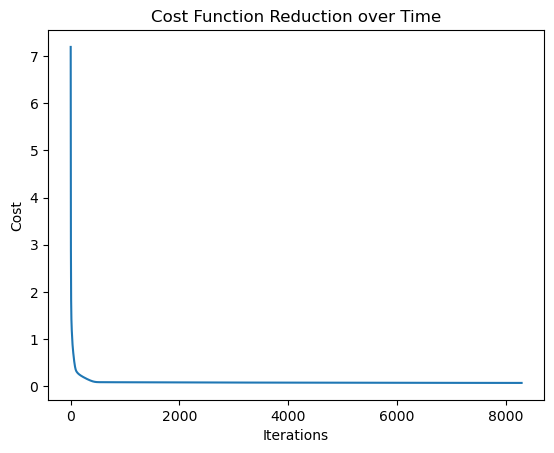

In [6]:
# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of the logistic regression class
log_reg = LogisticRegressionGD(learning_rate=0.01, max_iter=100000, delta_j=1e-6)

# Fit the model to the training data
log_reg.fit(X_train, y_train)
print("")

log_reg.plot_cost()

### Applying my logistic regression code

In [7]:
# Make predictions on the test set
predictions = log_reg.predict(X_test)

# Print the final accuracy
accuracy = np.mean(predictions == y_test)

print(f"My script accuracy: {accuracy:.2f}")
print("My script intercept:", log_reg.theta[0])
print("My script coefficients:", log_reg.theta[1:])

My script accuracy: 1.00
My script intercept: 1.5667833704305771
My script coefficients: [ 0.20831711 -0.07177945  0.06994173 -0.05989295 -0.02242114  0.0450106 ]


### Logistic Regression using sklearn

In [8]:
# Create an instance and fit the model
sklearn_log_reg = LogisticRegression(solver='liblinear', tol=1e-6)
sklearn_log_reg.fit(X_train, y_train)

# Make predictions
y_pred_sklearn = sklearn_log_reg.predict(X_test)

# Compute accuracy for sklearn model
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Sklearn accuracy: {accuracy_sklearn:.2f}")
print(f"Sklearn intercept: {sklearn_log_reg.intercept_}")
print(f"Sklearn coefficients: {sklearn_log_reg.coef_}")

Sklearn accuracy: 1.00
Sklearn intercept: [2.9626609]
Sklearn coefficients: [[ 0.26833918 -0.07915155  0.10123779 -0.06767857 -0.02659084  0.05432022]]


<br>
<br>

## Result summary:
### - The result when my code was used for the analysis was similar to the result gotten using the Sklearn logistic regression package.
### - Both models (mine and SKlearn) had high accuracy scores indicating good model performance.